In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx
from pyprojroot import here

from pyprojroot import here

import importlib.util

_spec = importlib.util.spec_from_file_location("opinion_functions", here() / "src" / "opinion_functions.py")
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
fun = _mod



In [2]:
# Real LaTeX rendering
mpl.rcParams['text.usetex'] = True
mpl.rcParams['text.latex.preamble'] = (
    r'\renewcommand{\familydefault}{\sfdefault}'
    r'\usepackage{amsmath}'
    r'\usepackage{xcolor}'
    r'\definecolor{majcolor}{HTML}{0091ff}'
    r'\definecolor{mincolor}{HTML}{f2d138}'
)
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']

maj_color      = '#0091ff'   # blue  -- majority
min_color      = '#f2d138'   # yellow -- minority (node fill)
min_text_color = '#9a7c00'   # dark goldenrod -- minority text (readable on white)
min_maj_color  = '#7fc960'   # green  -- cross-group edges
myblack        = '#222222'
greycolor      = '#888888'

SMALL_SIZE  = 8
MEDIUM_SIZE = 9
BIGGER_SIZE = 12

plt.rc('font',   size=SMALL_SIZE)
plt.rc('axes',   titlesize=SMALL_SIZE)
plt.rc('axes',   labelsize=MEDIUM_SIZE)
plt.rc('xtick',  labelsize=SMALL_SIZE)
plt.rc('ytick',  labelsize=SMALL_SIZE)
plt.rc('legend', fontsize=SMALL_SIZE)
plt.rc('figure', titlesize=BIGGER_SIZE)


In [3]:
# 3-node chain: blue (0) — yellow (1) — blue (2)
G = nx.Graph()
G.add_nodes_from([0, 1, 2])
G.add_edges_from([(0, 1), (1, 2)])

minority_nodes = {1}   # node 1 is the minority (yellow)

# Narcissistic perceived majority fraction per node
# (each node counts itself among its neighbors)
x_hat = {n: fun.assess_opinion(n, G, minority_nodes, narcissistic=True)
         for n in G.nodes()}

# True majority fraction in the network
majority_fraction = 2 / 3

# Per-node misperception: actual – perceived
beta = {n: majority_fraction - x_hat[n] for n in G.nodes()}

# Group-weighted misperception
beta_maj   = np.mean([beta[n] for n in [0, 2]])  # average over majority nodes
beta_min   = beta[1]                              # only minority node
beta_group = beta_maj * (2/3) + beta_min * (1/3)

print("x_hat  :", {n: round(v, 4) for n, v in x_hat.items()})
print("beta   :", {n: round(v, 4) for n, v in beta.items()})
print(f"beta_group = {beta_group:.6f}  (expected 1/9 = {1/9:.6f})")


x_hat  : {0: 0.5, 1: 0.6667, 2: 0.5}
beta   : {0: 0.1667, 1: 0.0, 2: 0.1667}
beta_group = 0.111111  (expected 1/9 = 0.111111)


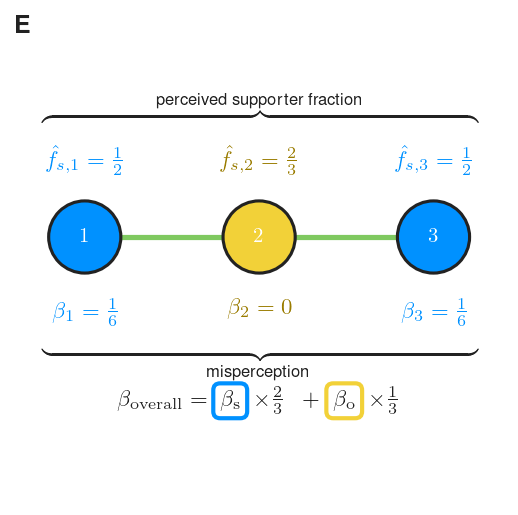

In [4]:
dpival = 150
fig, ax = plt.subplots(figsize=(4.2, 4.2), dpi=dpival)
ax.axis('off')
ax.set_xlim(-0.8, 4.8)
ax.set_ylim(-4.5, 3.8)

# ── Measure axes for cm ↔ data-unit conversions ───────────────────────
fig.canvas.draw()
rdr      = fig.canvas.get_renderer()
ax_bb    = ax.get_window_extent(renderer=rdr)
ax_w_in  = ax_bb.width  / fig.dpi
ax_h_in  = ax_bb.height / fig.dpi
x_range  = ax.get_xlim()[1] - ax.get_xlim()[0]
y_range  = ax.get_ylim()[1] - ax.get_ylim()[0]
du_per_cm_x = x_range / (ax_w_in  * 2.54)
du_per_cm_y = y_range / (ax_h_in  * 2.54)

y_shift = 0.5 * du_per_cm_y
x_shift = 0.2 * du_per_cm_x

pos = {0: (0, 0), 1: (2, 0), 2: (4, 0)}
annotation_color      = {0: maj_color,      1: min_color,      2: maj_color}
annotation_text_color = {0: maj_color,      1: min_text_color, 2: maj_color}

# ── Edges ────────────────────────────────────────────────────────────
nx.draw_networkx_edges(G, pos, edge_color=min_maj_color, width=2.5, ax=ax)

# ── Nodes ────────────────────────────────────────────────────────────
nx.draw_networkx_nodes(G, pos, nodelist=[0, 1, 2],
    node_size=1200,
    node_color=[annotation_color[n] for n in [0, 1, 2]],
    edgecolors=myblack, linewidths=1.5, ax=ax)

# ── Node index labels inside nodes ───────────────────────────────────
nx.draw_networkx_labels(G, pos,
    labels={0: r'$1$', 1: r'$2$', 2: r'$3$'},
    font_size=MEDIUM_SIZE + 1, font_color='white', font_weight='bold', ax=ax)

# ── f-hat labels above nodes ──────────────────────────────────────────
xhat_y = 0.55 + y_shift
xhat = {0: r'$\hat{f}_{s,1} = \frac{1}{2}$',
        1: r'$\hat{f}_{s,2} = \frac{2}{3}$',
        2: r'$\hat{f}_{s,3} = \frac{1}{2}$'}
for n, (x, y) in pos.items():
    ax.text(x, y + xhat_y, xhat[n], ha='center', va='bottom',
            fontsize=MEDIUM_SIZE + 2, color=annotation_text_color[n])

# ── beta labels below nodes ───────────────────────────────────────────
beta_y = 0.55 + y_shift
blabel = {0: r'$\beta_1 = \frac{1}{6}$',
          1: r'$\beta_2 = 0$',
          2: r'$\beta_3 = \frac{1}{6}$'}
for n, (x, y) in pos.items():
    ax.text(x, y - beta_y, blabel[n], ha='center', va='top',
            fontsize=MEDIUM_SIZE + 2, color=annotation_text_color[n])

# ── Brace width ───────────────────────────────────────────────────────
cm_per_unit = (ax_w_in * 2.54) / x_range
brace_x0, brace_x1 = -0.5, 4.5
brace_cm   = (brace_x1 - brace_x0) * cm_per_unit
brace_rule = r'\rule{' + f'{brace_cm:.3f}' + r'cm}{0pt}'
brace_fs   = MEDIUM_SIZE + 2

# ── Overbrace ─────────────────────────────────────────────────────────
t_ob = ax.text(2, 1.25 + y_shift,
               r'$\overbrace{' + brace_rule + r'}$',
               ha='center', va='bottom', fontsize=brace_fs, color=myblack)
fig.canvas.draw()
bb_ob    = t_ob.get_window_extent(rdr)
y_ob_top = ax.transData.inverted().transform((0, bb_ob.y1))[1]
ax.text(2, y_ob_top + 0.08, 'perceived supporter fraction',
        ha='center', va='bottom', fontsize=SMALL_SIZE, color=myblack)

# ── Underbrace ────────────────────────────────────────────────────────
t_ub = ax.text(2, -1.25 - y_shift,
               r'$\underbrace{' + brace_rule + r'}$',
               ha='center', va='top', fontsize=brace_fs, color=myblack)
fig.canvas.draw()
bb_ub    = t_ub.get_window_extent(rdr)
y_ub_bot = ax.transData.inverted().transform((0, bb_ub.y0))[1]
ax.text(2, y_ub_bot - 0.08, 'misperception',
        ha='center', va='top', fontsize=SMALL_SIZE, color=myblack)

# ── Overall formula ───────────────────────────────────────────────────
y_formula  = -2.9
fontsize_f = MEDIUM_SIZE + 2

pieces = [
    (r'$\beta_{\mathrm{overall}} =$',  None,       0.14),
    (r'$\beta_{\mathrm{s}}$',          maj_color,  0.05 + x_shift),
    (r'$\times\frac{2}{3}$',           None,       0.20),
    (r'$+$',                           None,       0.14),
    (r'$\beta_{\mathrm{o}}$',          min_color,  0.05 + x_shift),
    (r'$\times\frac{1}{3}$',           None,       0),
]

def make_bbox(color):
    return dict(boxstyle='round,pad=0.3', facecolor='none',
                edgecolor=color, linewidth=2) if color else None

placed = []
x_cur  = 0.0
for text_str, box_color, gap in pieces:
    t = ax.text(x_cur, y_formula, text_str, ha='left', va='baseline',
                fontsize=fontsize_f, color=myblack, bbox=make_bbox(box_color))
    placed.append(t)
    fig.canvas.draw()
    bb    = t.get_window_extent(renderer=rdr)
    x_cur = ax.transData.inverted().transform((bb.x1, bb.y0))[0] + gap

fig.canvas.draw()
x_left  = ax.transData.inverted().transform((placed[0].get_window_extent(rdr).x0, 0))[0]
x_right = ax.transData.inverted().transform((placed[-1].get_window_extent(rdr).x1, 0))[0]
offset  = 2.0 - (x_left + x_right) / 2
for t in placed:
    xp, yp = t.get_position()
    t.set_position((xp + offset, yp))

# ── Panel label E ─────────────────────────────────────────────────────
ax.text(0.0, 1.0, r'\textbf{E}', transform=ax.transAxes,
        fontsize=BIGGER_SIZE, color=myblack, ha='left', va='top')

plt.savefig(here('figures/figure_1_example.pdf'), bbox_inches='tight')
plt.show()
